<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        10 non-null     int64 
 1   balance    10 non-null     int64 
 2   geography  10 non-null     object
 3   gender     10 non-null     object
 4   churn      10 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 532.0+ bytes


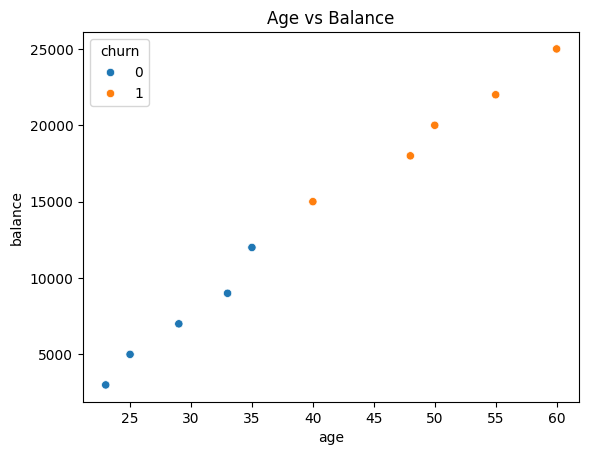

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Accuracy: 1.0
[[2]]


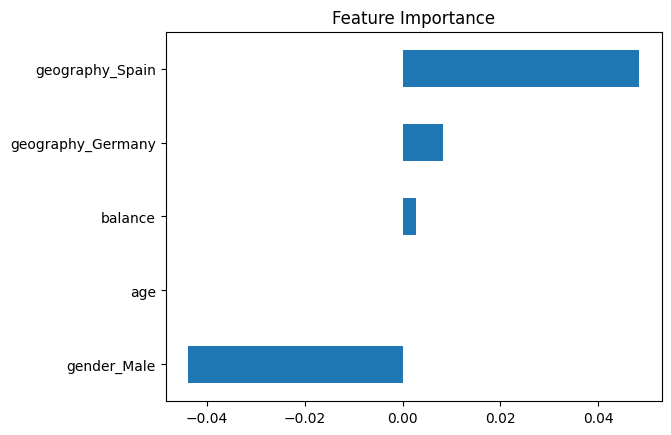

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
data = {
    'age': [25, 40, 35, 50, 23, 60, 48, 33, 55, 29],
    'balance': [5000, 15000, 12000, 20000, 3000, 25000, 18000, 9000, 22000, 7000],
    'geography': ['France', 'Germany', 'France', 'Spain', 'France', 'Germany', 'Spain', 'France', 'Germany', 'Spain'],
    'gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'churn': [0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
df
df.head()
df.info()
df = pd.get_dummies(df, columns=['geography', 'gender'], drop_first=True)
df
sns.scatterplot(x='age', y='balance', hue='churn', data=df)
plt.title("Age vs Balance")
plt.show()
X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()